# Recherche Tabou


Sections : imports, données, prétraitement, simulateur discret, Tabu Search, visualisation (Gantt) et exécution.

Fait par:

- Ouafa AIT OUAMER
- Hassan MAHAMAT IMAM


In [2]:
import random
import re
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch

# Fix random seed for reproducibility (change as needed)
random.seed(7)

In [8]:
# -----------------------------
# Données du problème
# -----------------------------
tasks = ["C1", "C2", "C3", "C4", "C5", "C6"]
# 1 unité = 5 minutes (ici on garde unité=1 pour simplicité dans l'exemple)
TASK_TIME = 1
SLOT_MINUTES = 1

# Capacité par compétence (peut être >1 si plusieurs soignants par compétence)
task_capacity: Dict[str, int] = {t: 1 for t in tasks}

# Table patients_operations (chaque sous-liste = colonnes successives)
patients_operations = [
    [["C1*2"], ["C1", "C2"], ["C1", "C3"], ["C1", "C2*2"], ["C4", "C5*2", "C6"]],
    [["C2", "C3"], ["C2", "C3"], ["C2"], [], []],
    [["C3*2"], ["C3"], [], [], []],
    [["C4*2"], ["C5", "C6"], ["C6*2"], ["C4*2"], ["C1", "C2"]],
    [["C2*2"], ["C5"], ["C5", "C6"], ["C4", "C5"], ["C3"]],
    [["C1"], ["C4"], ["C6"], [], []],
    [["C6*2"], ["C1"], ["C5", "C6"], ["C3"], []],
    [["C3", "C5"], ["C2", "C5"], ["C3", "C6"], ["C6"], []],
    [["C5"], ["C4"], ["C1"], [], []],
    [["C4"], ["C4", "C5"], ["C1", "C2"], ["C4"], []],
]

## Parsing & prétraitement
Fonctions pour parser les tokens comme `C1*2` et développer les étapes par patient en dictionnaires {skill: quantité}.

In [9]:
def parse_task(token: str) -> Tuple[str, int]:
    """
    Transforme 'Ck' ou 'Ck*x' en (skill, multiplicité).
    """
    m = re.fullmatch(r"(C\d+)(?:\*(\d+))?", token.strip())
    if not m:
        raise ValueError(f"Token de tâche invalide: {token}")
    skill = m.group(1)
    mult = int(m.group(2)) if m.group(2) else 1
    return skill, mult

def expand_patient_ops(p_ops: List[List[str]]) -> List[Dict[str, int]]:
    """
    Convertit la liste de colonnes d'un patient en liste de dictionnaires
    {skill: quantité} pour chaque étape.
    """
    stages: List[Dict[str, int]] = []
    for col in p_ops:
        counts: Dict[str, int] = {}
        for tok in col:
            skill, k = parse_task(tok)
            counts[skill] = counts.get(skill, 0) + k
        stages.append(counts)
    return stages

def preprocess(patients_ops: List[List[List[str]]]) -> List[List[Dict[str, int]]]:
    return [expand_patient_ops(p) for p in patients_ops]

## Simulateur discret du planning
La fonction `simulate` exécute la simulation tick par tick selon un ordre de priorité `order`.

In [10]:
def simulate(
    order: List[int],
    stages: List[List[Dict[str, int]]],
    capacities: Dict[str, int],
) -> Tuple[int, List[int]]:
    """
    Simule le planning une unité de temps après l'autre.
    - Priorité = ordre des patients donné.
    - Les tâches d'une même étape peuvent s'exécuter en parallèle si
      les compétences nécessaires sont disponibles.
    - Un patient ne peut passer à l'étape suivante qu'après fin complète
      de son étape en cours.

    Renvoie: (makespan_en_unites, [temps_de_fin_par_patient]).
    """
    n = len(stages)
    remaining = [[dict(d) for d in stages[i]] for i in range(n)]
    next_stage = [0] * n
    finished = [False] * n
    finish_times = [0] * n

    t = 0
    done = 0
    while done < n:
        # Promouvoir les patients dont l'étape courante est vide
        for i in range(n):
            if finished[i]:
                continue
            k = next_stage[i]
            while k < len(remaining[i]) and sum(remaining[i][k].values()) == 0:
                k += 1
            next_stage[i] = k
            if k >= len(remaining[i]):  # patient terminé
                finished[i] = True
                finish_times[i] = t
                done += 1

        if done >= n:
            break

        # Capacités disponibles pour ce tick
        avail = dict(capacities)
        progress = False

        # Allouer ressource par ressource en respectant l'ordre des patients
        for pid in order:
            if finished[pid]:
                continue
            k = next_stage[pid]
            if k >= len(remaining[pid]):
                continue
            stage = remaining[pid][k]
            # Greedy: un patient peut consommer toutes les unités dispo d'une compétence
            for s in list(stage.keys()):
                need = stage[s]
                if need <= 0:
                    continue
                cap = avail.get(s, 0)
                if cap <= 0:
                    continue
                take = min(need, cap)
                stage[s] -= take
                avail[s] -= take
                if take > 0:
                    progress = True

        if not progress:
            # En théorie ne doit pas arriver avec des capacités >=1
            raise RuntimeError("Blocage détecté: aucune progression dans ce tick.")

        t += 1

    return t, finish_times

## Tabu Search sur permutations
Voisinage: swap(i,j). Tabu stocke les paires échangées. Aspiration autorise les moves tabu s'ils améliorent le meilleur global.

In [11]:
def tabu_search(
    stages: List[List[Dict[str, int]]],
    capacities: Dict[str, int],
    max_iter: int = 800,
    tabu_tenure: int = 7,
    stop_no_improve: int = 30,
    seed: int = 0,
) -> Tuple[int, List[int]]:
    """
    Tabu Search avec voisinage 'swap (i, j)'.
    Tabu = paires (ID_patient_A, ID_patient_B) récemment échangées.
    Aspiration: on autorise un move tabu s'il améliore le meilleur global.
    """
    random.seed(seed)
    n = len(stages)

    # Heuristique d'initialisation: trier par quantité totale de travail décroissante
    def workload(i: int) -> int:
        return sum(v for d in stages[i] for v in d.values())

    current = sorted(range(n), key=workload, reverse=True)

    # Cache d'évaluations
    cache: Dict[Tuple[int, ...], int] = {}

    def cost(perm: List[int]) -> int:
        key = tuple(perm)
        if key not in cache:
            cache[key] = simulate(perm, stages, capacities)[0]
        return cache[key]

    best = current[:]
    best_cost = cost(best)

    tabu: Dict[Tuple[int, int], int] = {}  # move -> expiration (itération)
    no_imp = 0

    for it in range(1, max_iter + 1):
        best_neighbor = None
        best_neighbor_cost = float("inf")
        best_move = None

        for i in range(n - 1):
            for j in range(i + 1, n):
                cand = current[:]
                cand[i], cand[j] = cand[j], cand[i]
                move = tuple(sorted((current[i], current[j])))  # échanger ces patients

                c = cost(cand)
                is_tabu = tabu.get(move, -1) >= it
                # Aspiration: autoriser si meilleur que global
                if is_tabu and c >= best_cost:
                    continue

                if c < best_neighbor_cost or (
                    c == best_neighbor_cost and random.random() < 0.5
                ):
                    best_neighbor = cand
                    best_neighbor_cost = c
                    best_move = move

        # Si tous les moves sont tabu sans aspiration, on "débloque"
        if best_neighbor is None:
            tabu.clear()
            continue

        current = best_neighbor
        current_cost = best_neighbor_cost

        # Mettre à jour la liste tabu
        tabu[best_move] = it + tabu_tenure

        # Mettre à jour le meilleur global
        if current_cost < best_cost:
            best = current[:]
            best_cost = current_cost
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= stop_no_improve:
                break

    return best_cost, best

## GANTT : simulation + tracé
Fonctions pour journaliser les allocations unité-par-unité et tracer un Gantt par compétence/soignant.

In [12]:
def simulate_with_gantt(order, stages, capacities):
    n = len(stages)
    remaining = [[dict(d) for d in stages[i]] for i in range(n)]
    next_stage = [0] * n
    finished = [False] * n
    finish_times = [0] * n

    log = []  # affectations unité-par-unité (durée = 1)

    t = 0
    done = 0
    while done < n:
        # Promotion en début de tick
        for i in range(n):
            if finished[i]:
                continue
            k = next_stage[i]
            while k < len(remaining[i]) and sum(remaining[i][k].values()) == 0:
                k += 1
            next_stage[i] = k
            if k >= len(remaining[i]):
                finished[i] = True
                finish_times[i] = t
                done += 1

        if done >= n:
            break

        # Soignants disponibles par compétence (indices 0..cap-1)
        free = {s: list(range(capacities.get(s, 0))) for s in capacities}
        progress = False

        # Allouer 1 unité à la fois, en respectant l'ordre des patients
        for pid in order:
            if finished[pid]:
                continue
            k = next_stage[pid]
            if k >= len(remaining[pid]):
                continue
            stage = remaining[pid][k]

            for s in list(stage.keys()):
                while stage[s] > 0 and free.get(s):
                    r = free[s].pop(0)  # index du soignant
                    stage[s] -= 1
                    progress = True
                    log.append({"t": t, "skill": s, "res": r, "patient": pid, "stage": k})

        if not progress:
            raise RuntimeError("Blocage détecté: aucune progression dans ce tick.")
        t += 1

    return t, finish_times, log

def _compress_log(log):
    lanes = {}
    for e in log:
        key = (e["skill"], e["res"])
        lanes.setdefault(key, []).append((e["t"], e["patient"], e["stage"]))

    merged = {}
    for key, items in lanes.items():
        items.sort()  # tri par temps croissant
        blocks = []
        if not items:
            merged[key] = blocks
            continue
        start, patient, stage = items[0]
        dur = 1
        prev_t = start
        for t, p, s in items[1:]:
            if p == patient and s == stage and t == prev_t + 1:
                dur += 1
            else:
                blocks.append((start, dur, patient, stage))
                start, patient, stage = t, p, s
                dur = 1
            prev_t = t
        blocks.append((start, dur, patient, stage))
        merged[key] = blocks
    return merged

def plot_gantt_from_log(log, capacities, slot_minutes=5, title="Gantt par compétence"):
    merged = _compress_log(log)

    # Ordre des lanes
    lane_keys = []
    for s in sorted(capacities.keys()):
        for r in range(capacities[s]):
            lane_keys.append((s, r))
    y_pos = {key: i for i, key in enumerate(lane_keys[::-1])}
    nlanes = len(lane_keys)

    # Couleurs patients
    cmap = matplotlib.colormaps.get_cmap("tab20")

    def pcolor(p):
        return cmap(p % cmap.N)

    makespan_units = (
        max(
            (start + dur) for blocks in merged.values() for (start, dur, _, _) in blocks
        )
        if merged
        else 0
    )
    width_in = max(10, makespan_units * slot_minutes / 6)
    height_in = max(4, nlanes * 0.6)
    fig, ax = plt.subplots(figsize=(width_in, height_in))

    for key, blocks in merged.items():
        y = y_pos[key]
        for start, dur, p, stage in blocks:
            left = start * slot_minutes
            width = dur * slot_minutes
            ax.barh(
                y=y,
                width=width,
                left=left,
                height=0.8,
                color=pcolor(p),
                edgecolor="black",
                linewidth=0.3,
            )
            label = f"P{p + 1}-O{stage + 1}"
            fontsize = 9 if width >= 15 else 7
            ax.text(
                left + width / 2,
                y,
                label,
                va="center",
                ha="center",
                fontsize=fontsize,
                color="white",
            )

    ax.set_xlabel("Minutes")
    ax.set_ylabel("Compétences (soignants)")
    ax.set_title(title)
    yticks, ylabels = [], []
    for key, y in sorted(y_pos.items(), key=lambda kv: kv[1]):
        s, r = key
        yticks.append(y)
        ylabels.append(s if capacities[s] == 1 else f"{s}#{r + 1}")
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.grid(True, axis="x", linestyle="--", alpha=0.4)
    ax.set_xlim(0, makespan_units * slot_minutes)

    patients_ids = sorted({e["patient"] for e in log})
    handles = [Patch(facecolor=pcolor(p), label=f"Patient {p + 1}") for p in patients_ids]
    ax.legend(handles=handles, loc="upper right", ncols=2, fontsize=8, frameon=True)

    plt.tight_layout()
    plt.show()

def plot_best_gantt(best_order, patients_stages, capacities, slot_minutes=5):
    mk, finish, log = simulate_with_gantt(best_order, patients_stages, capacities)
    print("Makespan (unités) =", mk, "=>", mk * slot_minutes, "minutes")
    plot_gantt_from_log(
        log,
        capacities,
        slot_minutes=slot_minutes,
        title=f"Gantt (ordre={[i + 1 for i in best_order]}, Cmax={mk} unités)",
    )

## Exécution (main)  & Diagramme de Gantt 

Prétraitement, exécution du Tabu Search et traçage du Gantt pour la meilleure solution.

Makespan (unités) = 12 => 12 minutes


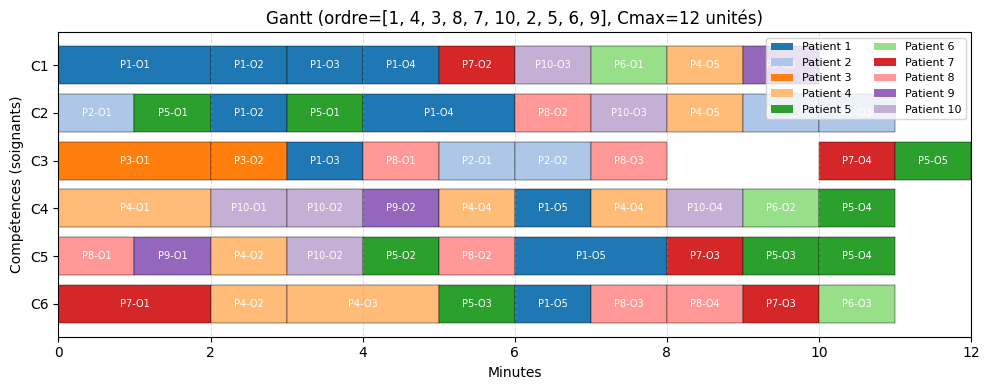

Ordre trouvé (patients): [1, 4, 3, 8, 7, 10, 2, 5, 6, 9]
Makespan: 12 unités (12 minutes)
Temps de fin par patient (unités): [8, 11, 3, 9, 12, 11, 11, 9, 10, 9]


In [13]:
# Prétraitement
patients_stages = preprocess(patients_operations)

# Lancer Tabu Search (paramètres modifiables)
best_units, best_order = tabu_search(
    patients_stages,
    task_capacity,
    max_iter=800,
    tabu_tenure=7,
    stop_no_improve=30,
    seed=42,
)

# Afficher Gantt pour la meilleure solution
plot_best_gantt(best_order, patients_stages, task_capacity, slot_minutes=SLOT_MINUTES)

minutes = best_units * TASK_TIME * SLOT_MINUTES
human_order = [p + 1 for p in best_order]  # pour afficher patients 1..N

print("Ordre trouvé (patients):", human_order)
print(f"Makespan: {best_units} unités ({minutes} minutes)")

# Vérification rapide
final_units, finish_times = simulate(best_order, patients_stages, task_capacity)
assert final_units == best_units
print("Temps de fin par patient (unités):", finish_times)

# Resultat final de la Recherche Tabou

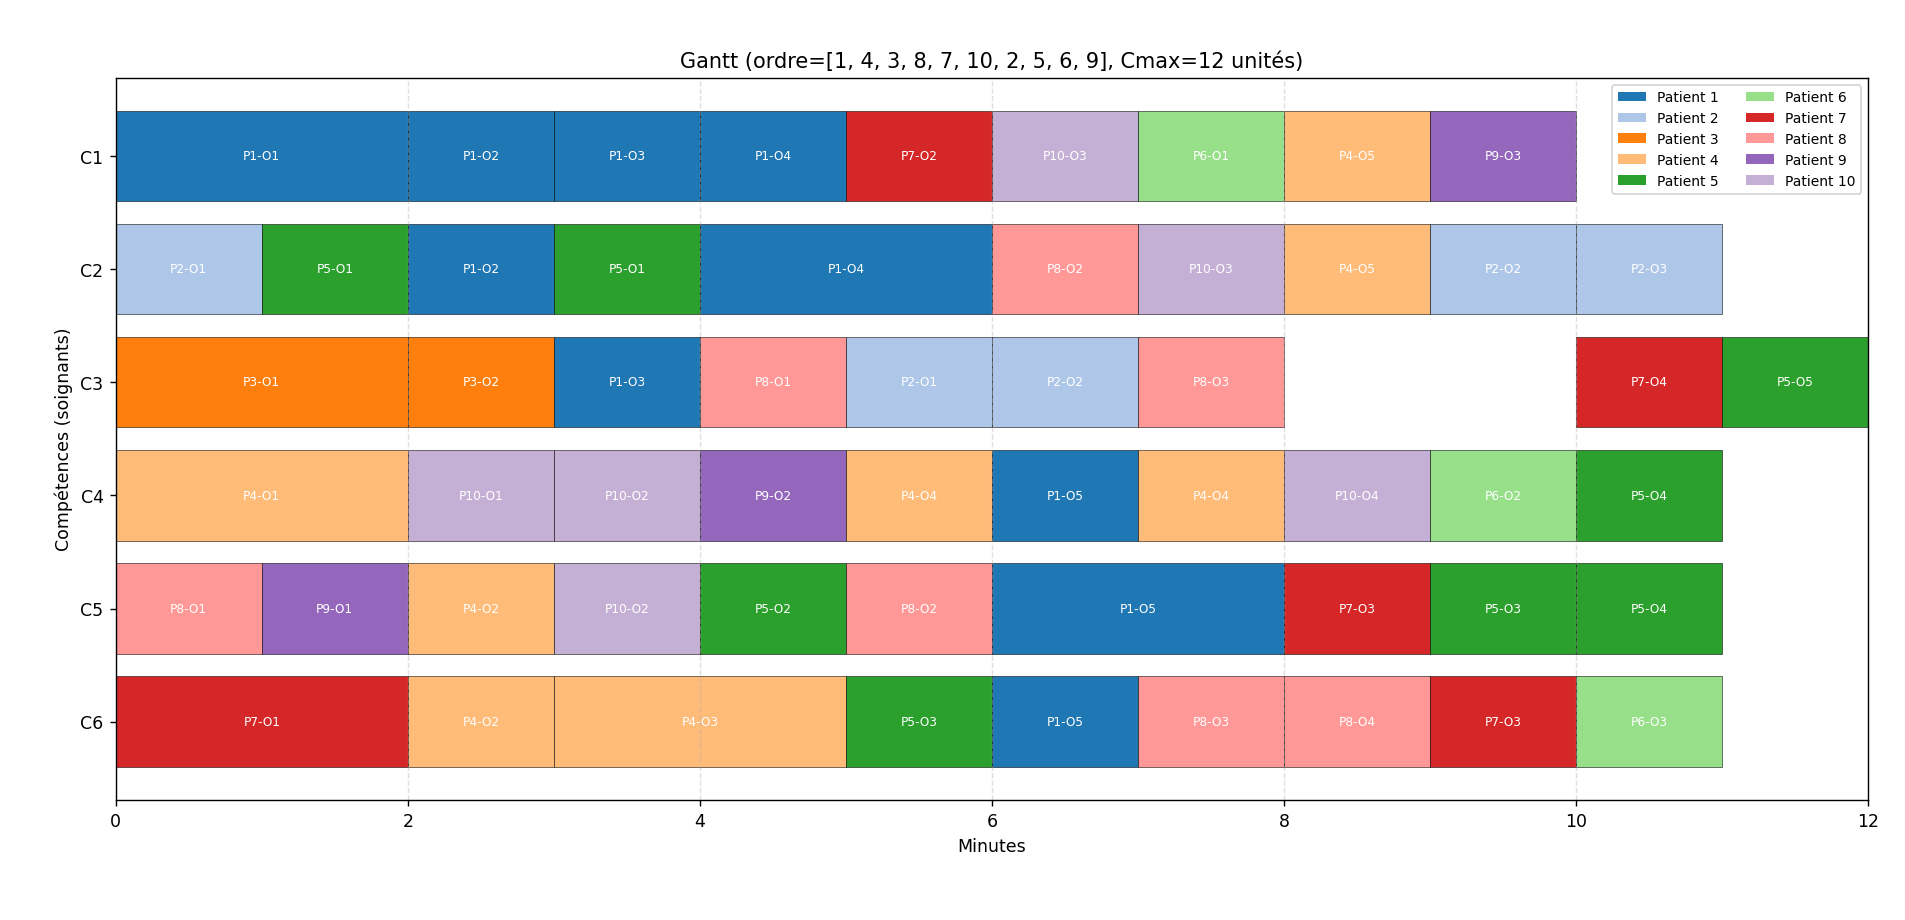

Ordre trouvé (patients): [1, 4, 3, 8, 7, 10, 2, 5, 6, 9]   
Makespan: 12 unités (12 minutes)  
Temps de fin par patient (unités): [8, 11, 3, 9, 12, 11, 11, 9, 10, 9]

# Conclusion

Diagramme de Gantt pour la recherche Tabou :
●	Les exécutions parallèles des tâches sur C1 à C6.
●	La fin de l’ordonnancement vers 12 unités de temps et le coût minimal (12).
●	Les phases de forte concurrence et les périodes d’inactivité.